# 기계학습기초 팀 프로젝트

## KNHANES 2022 기반 수면시간·청각 문제와 우울 위험군 예측

- 팀명: 5팀
- 데이터: 국민건강영양조사 제9기 1차년도(2022년)
- 사용 데이터 형태: 이미 하나의 데이터셋으로 병합된 KNHANES 원시자료
- 주제: 수면시간, 청각 문제, 소음 노출 관련 변수를 활용한 우울 위험군 이진 분류
- 최종 산출물: 데이터 분석 전 과정을 포함한 Jupyter Notebook

---

# 0. 프로젝트 개요

## 0.1 연구 배경

본 프로젝트는 국민건강영양조사 제9기 1차년도(2022년) 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 요인과 우울 위험군 사이의 관계를 분석한다.

## 0.2 문제 정의

- 입력 변수: 수면시간, 청각 상태, 직업적 소음 노출, 이명, 이어폰 소음 노출, 청각 활동제한 관련 변수
- 타깃 변수: PHQ-9 총점 기반 우울 위험군 여부
- 문제 유형: 지도학습 기반 이진 분류

## 0.3 분석 목표

- PHQ-9 총점 10점 이상 여부를 기준으로 우울 위험군 예측
- 수면 및 청각 관련 변수의 예측 기여도 확인
- 여러 분류 모델의 성능 비교
- 변수 중요도 및 도메인 관점 해석

## 0.4 분석 시 주의점

본 프로젝트에서는 이미 하나의 파일로 병합된 KNHANES 데이터를 사용하므로 별도의 데이터 병합 과정은 수행하지 않는다. 또한 PHQ-9 총점에는 수면 관련 문항이 포함되어 있으므로, 수면시간 변수와 우울 위험군 타깃 사이에 개념적 중복 가능성이 있음을 한계점에서 함께 해석한다.

---

# 1. 라이브러리 및 기본 설정

In [5]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

---

# 2. 데이터 불러오기

## 2.1 사용 데이터

국민건강영양조사 제9기 1차년도(2022년) 자료 중 이미 병합되어 있는 단일 데이터셋을 사용한다.

아래 코드에서 `file_path`만 실제 파일명에 맞게 수정하면 된다.

In [6]:
# 사용 중인 파일명에 맞게 수정하세요.
# 예: "hn22_all.sas7bdat", "final_dataset.csv", "knhanes_2022.csv"
file_path = "./hn22_all.sas7bdat"

if file_path.endswith(".sas7bdat"):
    df_raw = pd.read_sas(file_path, format="sas7bdat")
elif file_path.endswith(".csv"):
    df_raw = pd.read_csv(file_path)
elif file_path.endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(file_path)
else:
    raise ValueError("지원하지 않는 파일 형식입니다. sas7bdat, csv, xlsx 중 하나를 사용하세요.")

# SAS 파일에서 문자형 변수가 bytes로 읽히는 경우 디코딩
for col in df_raw.columns:
    if df_raw[col].dtype == "object":
        df_raw[col] = df_raw[col].apply(
            lambda x: x.decode("cp949", errors="ignore") if isinstance(x, bytes) else x
        )

print("데이터 크기:", df_raw.shape)
df_raw.head()

데이터 크기: (6265, 685)


,mod_d,ID,ID_fam,year,region,town_t,apt_t,psu,sex,age,age_month,incm,ho_incm,incm5,ho_incm5,edu,occp,wt_hs,wt_itvex,wt_oe,wt_bia,wt_ntr,wt_tot,wt_oent,wt_biant,kstrata,cfam,genertn,allownc,house,live_t,ainc_unit1,ainc_1,ainc,marri_1,marri_2,fam_rela,tins,npins,ID_F,ID_M,D_1_1,D_2_1,D_2_wk,DI1_dg,DI1_ag,DI1_pr,DI1_pt,DI1_2,DI2_dg,...,Y_MLK_ST,Y_WN_ST,Y_SUP_YN,Y_SUP_KD1,Y_SUP_KD3,Y_SUP_KD4,Y_SUP_KD7,N_DIET,N_DIET_WHY,N_DT_DS,N_DT_ETC,N_WAT_C,N_BF,N_BFD_Y,N_DAY,N_INTK,N_EN,N_WATER,N_PROT,N_FAT,N_SFA,N_MUFA,N_PUFA,N_N3,N_N6,N_CHOL,N_CHO,N_TDF,N_SUGAR,N_CA,N_PHOS,N_NA,N_K,N_MG,N_FE,N_ZN,N_VA_RAE,N_VITD,N_VITE,N_CAROT,N_RETIN,N_B1,N_B2,N_NIAC,N_FOLATE,N_VITC,LF_secur_y,LF_BUYER,LF_SAFE,N_DUSUAL
0,2026.02.27.,YA01220302,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,56.0,NaN,3.0,4.0,4.0,4.0,3.0,7.0,7834.391511,9090.322425,10783.493262,11291.368622,10346.361689,10343.746528,11265.895141,11741.501904,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,1.0,1.0,2.0,10.0,1.0,NaN,NaN,3.0,2.0,88.0,1.0,48.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,3.5,2.0,8.0,수요일,849.465975,1460.144833,513.082135,58.852416,28.463777,8.017655,9.421072,7.647123,0.882515,6.761384,40.991353,238.931003,29.240249,44.705424,498.323785,1003.351910,1273.050326,2480.515348,371.132271,10.380525,10.240582,454.396392,2.150000,7.365415,853.187240,383.340000,0.814587,1.182300,10.042185,291.264557,32.441192,1.0,NaN,1.0,3
1,2026.02.27.,YA01220303,YA012203,2022.0,1.0,1.0,2.0,YA01,1.0,30.0,NaN,3.0,4.0,3.0,4.0,4.0,3.0,7834.391511,13042.142562,20078.947634,19822.942221,19763.950889,19666.742049,21352.961071,20820.115372,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,14.9,8.0,8.0,수요일,1441.052658,1971.535569,998.779824,98.998643,59.509129,14.244400,25.674881,11.391725,0.802900,10.573850,361.378293,268.663768,47.771905,102.638985,742.705707,1692.230686,1968.873043,3676.696548,520.241317,19.408543,14.736918,815.571495,5.498400,11.608507,973.767210,732.385000,1.829417,2.017004,18.342991,329.385371,79.903529,1.0,NaN,1.0,3
2,2026.02.27.,YA01220304,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,25.0,NaN,3.0,4.0,4.0,4.0,4.0,7.0,7834.391511,9895.727513,14566.872199,14931.827386,14314.436646,14510.887963,15616.336412,15501.618290,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,1.0,3.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,10.0,2.0,8.0,수요일,377.138748,1164.875037,131.628999,22.740898,39.650722,13.289250,15.123441,8.740357,0.354360,7.035220,0.961147,176.112561,10.117903,26.400092,423.150590,300.822929,1498.745141,783.549944,105.706399,2.591360,2.285068,14.093456,0.000000,8.502485,166.686411,0.000000,0.262020,1.379288,3.042505,69.694336,2.776080,1.0,1.0,1.0,2
3,2026.02.27.,YA01236501,YA012365,2022.0,1.0,1.0,2.0,YA01,1.0,66.0,NaN,3.0,3.0,4.0,3.0,4.0,7.0,7834.391511,6438.920648,7251.845005,7542.480144,7068.650323,7051.216076,7843.924333,8088.513725,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,1.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,8.0,8.0,화요일,3245.543916,2213.970700,2744.107388,91.387506,66.330671,16.131310,23.075432,18.333469,3.835584,14.137622,325.006948,321.141632,48.315870,65.847307,552.891309,1441.801023,4157.860611,4448.107487,480.592319,16.433790,17.301592,407.893533,3.230366,9.215554,3676.549476,100.898983,1.338621,2.325439,18.325182,633.687278,112.775603,1.0,NaN,1.0,2
4,2026.02.27.,YA01236502,YA012365,2022.0,1.0,1.0,2.0,YA01,2.0,62.0,NaN,3.0,3.0,3.0,3.0,3.0,6.0,7834.391511,5593.752658,6857.115069,7064.391215,6434.393479,6420.343834,7194.949559,7421.746687,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,2.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,2.0,8.0,화요일,2864.424520,2062.847547,2392.725794,93.020540,64.847477,16.525857,24.244867,15.025077,3.119590,1

---

# 3. 데이터 구조 확인 및 분석 변수 정리

이 단계에서는 병합을 수행하지 않고, 이미 병합된 데이터셋에서 분석에 필요한 변수들이 존재하는지 확인한다.

## 3.1 주요 변수 영역

- 수면시간: `BP16_1`, `BP16_2`
- 청력 자가보고: `T_Q_HR`
- 청각보조기기: `T_Q_HR_1`, `T_Q_HR_2`
- 직업적 소음 노출: `T_NQ_OCP`
- 이어폰 소음 노출: `T_NQ_PH2`, `T_NQ_PH2_T`
- 이명 경험: `T_Q_VN`, `T_Q_VN_1`, `T_Q_VN_2`
- 활동제한: `LQ4_00`, `LQ4_13`
- PHQ-9 문항: `BP_PHQ_1` ~ `BP_PHQ_9`
- PHQ-9 총점: `mh_PHQ_S`

In [7]:
# 사용하는 열 코드북
USE_COLS = {
    # ID
    "ID": "id",

    # Sleep
    "BP16_1": "wkdy_sleep_hours",      # 주중 하루 평균 수면시간
    "BP16_2": "wknd_sleep_hours",      # 주말 하루 평균 수면시간

    # Hearing
    "T_Q_HR": "hear_status",           # 본인 청력 상태
    "T_Q_HR_1": "hear_device",         # 청각보조기기 사용 종류
    "T_Q_HR_2": "hear_device_freq",    # 청각보조기기 사용 빈도

    # Noise exposure
    "T_NQ_OCP": "occ_noise",           # 직업적 소음 노출
    "T_NQ_PH2": "ear_noise",           # 시끄러운 장소에서 이어폰 사용 경험
    "T_NQ_PH2_T": "ear_noise_min",     # 이어폰 사용 시간

    # Tinnitus
    "T_Q_VN": "tinnitus",              # 이명 경험
    "T_Q_VN_1": "tinnitus_6mo",        # 이명 6개월 이상 지속 여부
    "T_Q_VN_2": "tinnitus_dist",       # 이명 괴로움 수준

    # Activity limitation
    "LQ4_00": "act_limit",             # 활동제한 여부
    "LQ4_13": "hear_act_limit",        # 청각 문제로 인한 활동제한

    # PHQ-9 items
    "BP_PHQ_1": "phq_1",
    "BP_PHQ_2": "phq_2",
    "BP_PHQ_3": "phq_3",
    "BP_PHQ_4": "phq_4",
    "BP_PHQ_5": "phq_5",
    "BP_PHQ_6": "phq_6",
    "BP_PHQ_7": "phq_7",
    "BP_PHQ_8": "phq_8",
    "BP_PHQ_9": "phq_9",

    # PHQ-9 total score
    "mh_PHQ_S": "phq_score",
}

required_cols = list(USE_COLS.keys())
missing_cols = [col for col in required_cols if col not in df_raw.columns]
existing_cols = [col for col in required_cols if col in df_raw.columns]

print("분석 후보 변수 수:", len(required_cols))
print("존재하는 변수 수:", len(existing_cols))
print("누락 변수 수:", len(missing_cols))

if missing_cols:
    print("누락 변수:", missing_cols)
else:
    print("모든 분석 후보 변수가 데이터에 존재합니다.")

분석 후보 변수 수: 24
존재하는 변수 수: 24
누락 변수 수: 0
모든 분석 후보 변수가 데이터에 존재합니다.


In [8]:
# 존재하는 변수만 우선 선택한다.
# 단, 핵심 변수 누락이 있다면 코드북 또는 실제 컬럼명을 확인해야 한다.
df_selected = df_raw[existing_cols].rename(columns={k: v for k, v in USE_COLS.items() if k in existing_cols}).copy()

print(df_selected.shape)
df_selected.head()

(6265, 24)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,phq_9,phq_score
0,YA01220302,8.0,10.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,1.0,0.0,0.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,7.0
1,YA01220303,7.0,7.0,1.0,8.0,8.0,8.0,2.0,8888.0,8.0,8.0,88.0,2.0,8.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,6.0
2,YA01220304,6.0,8.0,1.0,8.0,8.0,8.0,1.0,20.0,8.0,8.0,88.0,2.0,8.0,0.0,1.0,3.0,3.0,2.0,0.0,1.0,0.0,1.0,11.0
3,YA01236501,9.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,YA01236502,7.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

# 4. 결측 및 비해당 코드 처리

KNHANES 설문 변수에는 비해당, 모름, 무응답 등의 코드가 포함될 수 있다. 분석 전에 이러한 값을 결측으로 처리한다.

주의: 변수별 코드북에 따라 결측 코드의 의미가 다를 수 있으므로, 최종 분석 전에는 반드시 코드북을 확인해야 한다. 아래 코드는 프로젝트 진행을 위한 기본 처리 예시이다.

## 전처리 결정 근거 (EDA 기반)

| 변수 | 처리 방법 | 근거 |
|------|-----------|------|
| `hear_device_freq` | missing indicator 생성 후 원본 제거 | 결측률 **98.5%** — 대부분 비해당자로 결측 자체가 정보를 가짐 |
| `wknd_sleep_hours` | `clip(2, 16)` 이상치 클리핑 | IQR 기준 이상치 비율 **21.3%** — 수면시간 물리적 범위 적용 |
| `wkdy_sleep_hours` | `clip(2, 16)` 이상치 클리핑 | 동일 기준 적용 (일관성 유지) |
| `act_limit` | 결측 median 대체 (파이프라인) | 타깃 상관 1위 (r = −0.209) — 제거하지 않고 유지 |

In [9]:
# object 타입 컬럼만 숫자 변환 시도 (ID 등 문자형 식별자 제외)
# pandas 최신버전에서 errors="ignore"가 제거되어 select_dtypes로 대체
for col in df_selected.select_dtypes(include="object").columns:
    if col != "id":
        df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

# 분석 변수별 결측 코드 처리 (코드북 기준)
missing_code_map = {
    "wkdy_sleep_hours":  [88, 99, 888, 999],
    "wknd_sleep_hours":  [88, 99, 888, 999],
    "hear_status":       [8, 9, 88, 99],
    "hear_device":       [8, 9, 88, 99],
    "hear_device_freq":  [8, 9, 88, 99],
    "occ_noise":         [8, 9, 88, 99],
    "ear_noise":         [8, 9, 88, 99],
    "ear_noise_min":     [888, 999, 8888, 9999],
    "tinnitus":          [8, 9, 88, 99],
    "tinnitus_6mo":      [8, 9, 88, 99],
    "tinnitus_dist":     [8, 9, 88, 99],
    "act_limit":         [8, 9, 88, 99],
    "hear_act_limit":    [8, 9, 88, 99],
    "phq_1": [8, 9], "phq_2": [8, 9], "phq_3": [8, 9],
    "phq_4": [8, 9], "phq_5": [8, 9], "phq_6": [8, 9],
    "phq_7": [8, 9], "phq_8": [8, 9], "phq_9": [8, 9],
    "phq_score": [88, 99, 888, 999],
}

for col, codes in missing_code_map.items():
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].replace(codes, np.nan)

# 수면시간 물리적으로 불가능한 값 처리
for col in ["wkdy_sleep_hours", "wknd_sleep_hours"]:
    if col in df_selected.columns:
        df_selected.loc[(df_selected[col] < 0) | (df_selected[col] > 24), col] = np.nan

print("결측 처리 후 데이터 크기:", df_selected.shape)
df_selected.isna().mean().sort_values(ascending=False).head(20)

결측 처리 후 데이터 크기: (6265, 24)


hear_device_freq    0.984358
tinnitus_dist       0.938707
tinnitus_6mo        0.932003
ear_noise_min       0.893376
hear_device         0.881724
hear_act_limit      0.861612
tinnitus            0.412450
occ_noise           0.412450
phq_score           0.226656
phq_2               0.224900
phq_1               0.224741
phq_3               0.224741
phq_4               0.224741
phq_7               0.224581
phq_8               0.224581
phq_5               0.224262
phq_6               0.224262
phq_9               0.224262
act_limit           0.184517
ear_noise           0.179090
dtype: float64

---

# 5. 타깃 변수 생성: PHQ-9 기반 우울 위험군

PHQ-9 총점이 10점 이상이면 우울 위험군으로 정의한다.

- 우울 위험군: `1`
- 비위험군: `0`

이 노트북에서는 `mh_PHQ_S`에서 가져온 `phq_score`를 우선 사용한다. `phq_score`가 없는 경우에는 PHQ-9 문항 9개를 합산하여 총점을 계산한다.

In [10]:
# PHQ-9에서 3번 문항(수면 문항) 제외
# → 수면시간 변수(BP16_1, BP16_2)와 개념적 중복 방지 (데이터 누수)
phq_items_no3 = [f"phq_{i}" for i in range(1, 10) if i != 3]  # phq_3 제외

# 각 PHQ 문항 유효 범위 처리: 0~3만 유효, 그 외 → NaN
for col in phq_items_no3:
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].where(df_selected[col].between(0, 3), np.nan)

# PHQ-8 총점 계산: 8문항 중 하나라도 결측이면 총점 NaN (skipna=False)
available_items = [col for col in phq_items_no3 if col in df_selected.columns]
df_selected["phq8_score"] = df_selected[available_items].sum(axis=1, skipna=False)

# 우울 위험군 정의: PHQ-8 총점 7점 이상 → 1, 미만 → 0, 결측 → NaN
df_selected["depression_risk"] = np.where(
    df_selected["phq8_score"].isna(), np.nan,
    (df_selected["phq8_score"] >= 7).astype(int)
)

print("=== PHQ-8 총점 기술 통계 (phq_3 수면 문항 제외) ===")
print(df_selected["phq8_score"].describe().round(2))
print(f"\n결측 (8문항 중 1개 이상 무응답): {df_selected['phq8_score'].isna().sum()}명")

print("\n=== 타깃 변수 분포 ===")
print(df_selected["depression_risk"].value_counts(dropna=False))
print(df_selected["depression_risk"].value_counts(normalize=True, dropna=False).round(3))

=== PHQ-8 총점 기술 통계 (phq_3 수면 문항 제외) ===
count    4846.00
mean        1.85
std         2.99
min         0.00
25%         0.00
50%         1.00
75%         3.00
max        24.00
Name: phq8_score, dtype: float64

결측 (8문항 중 1개 이상 무응답): 1419명

=== 타깃 변수 분포 ===
depression_risk
0.0    4516
NaN    1419
1.0     330
Name: count, dtype: int64
depression_risk
0.0    0.721
NaN    0.226
1.0    0.053
Name: proportion, dtype: float64


---

# 6. 모델링 데이터 구성

PHQ-9 문항과 PHQ-9 총점은 타깃 생성에 사용된 변수이므로 모델 입력 변수에서는 제외한다. 식별자인 `id` 역시 모델 입력에 포함하지 않는다.

In [11]:
FEATURE_COLS = [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "hear_status",
    "hear_device",
    "hear_device_freq",   # 결측률 98.5% → missing indicator 생성 후 원본 제거
    "occ_noise",
    "ear_noise",
    "ear_noise_min",
    "tinnitus",
    "tinnitus_6mo",
    "tinnitus_dist",
    "act_limit",          # 타깃 상관 1위 (r=-0.209) → 유지
    "hear_act_limit",
]

available_features = [col for col in FEATURE_COLS if col in df_selected.columns]
model_cols = [col for col in ["id"] + available_features + ["depression_risk"] if col in df_selected.columns]

df_model = df_selected[model_cols].copy()
df_model = df_model.dropna(subset=["depression_risk"])
df_model["depression_risk"] = df_model["depression_risk"].astype(int)

# ============================================================
# 6-1. 코드북 기반 의미 중심 전처리
# ============================================================

# 1) 청각보조기기 사용 여부
# T_Q_HR_1: 1=보청기, 2=인공와우, 3=사용하지 않음
df_model["hear_device_use"] = np.select(
    [
        df_model["hear_device"].isin([1, 2]),
        df_model["hear_device"].eq(3)
    ],
    [1, 0],
    default=np.nan
)

# 청각보조기기 사용 빈도
# 사용하지 않는 사람은 '빈도 없음'이므로 0으로 처리
# 사용하는 사람인데 빈도 응답이 없으면 결측으로 유지
df_model["hear_device_freq_ord"] = df_model["hear_device_freq"].copy()
df_model.loc[df_model["hear_device_use"].eq(0), "hear_device_freq_ord"] = 0

# 실제 사용자 중 빈도 결측 여부
df_model["hear_device_freq_unknown"] = (
    df_model["hear_device_use"].eq(1) & df_model["hear_device_freq"].isna()
).astype(int)

# 2) 직업적 소음 노출
df_model["occ_noise_yes"] = df_model["occ_noise"].replace({
    1: 1,
    2: 0
})

# 3) 시끄러운 장소에서 이어폰 사용 여부
df_model["ear_noise_use"] = df_model["ear_noise"].replace({
    1: 1,
    2: 0
})

# 이어폰 사용 경험이 없는 사람은 사용시간 0분으로 처리
df_model["ear_noise_min_clean"] = df_model["ear_noise_min"].copy()
df_model.loc[df_model["ear_noise_use"].eq(0), "ear_noise_min_clean"] = 0

# 이어폰 사용한다고 했는데 사용시간이 결측인 경우만 결측 플래그
df_model["ear_noise_min_missing"] = (
    df_model["ear_noise_use"].eq(1) & df_model["ear_noise_min"].isna()
).astype(int)

# 4) 이명 여부
df_model["tinnitus_use"] = df_model["tinnitus"].replace({
    1: 1,
    2: 0
})

# 이명이 없는 사람은 6개월 이상 지속 여부도 0으로 처리
df_model["tinnitus_6mo_yes"] = df_model["tinnitus_6mo"].replace({
    1: 1,
    2: 0
})
df_model.loc[df_model["tinnitus_use"].eq(0), "tinnitus_6mo_yes"] = 0

# 이명 괴로움 정도
# 이명이 없는 사람은 괴로움 정도 0으로 처리
df_model["tinnitus_dist_score"] = df_model["tinnitus_dist"].copy()
df_model.loc[df_model["tinnitus_use"].eq(0), "tinnitus_dist_score"] = 0

# 5) 활동제한 여부
# LQ4_00은 1=예, 2=아니오 구조로 보고 이진화
df_model["act_limit_yes"] = df_model["act_limit"].replace({
    1: 1,
    2: 0
})

# 청각 문제로 인한 활동제한
df_model["hear_act_limit_yes"] = df_model["hear_act_limit"].replace({
    1: 1,
    2: 0
})

# 전체 활동제한이 없는 사람은 청각 문제로 인한 활동제한도 0으로 처리
df_model.loc[df_model["act_limit_yes"].eq(0), "hear_act_limit_yes"] = 0

# 6) 수면시간 클리핑
# 0~24시간 외 값은 이미 결측 처리했고, 모델링에서는 극단값 완화
for col in ["wkdy_sleep_hours", "wknd_sleep_hours"]:
    df_model[col] = df_model[col].clip(lower=2, upper=16)

print("모델링용 데이터 크기:", df_model.shape)
df_model.head()

모델링용 데이터 크기: (4846, 27)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,depression_risk,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes
0,YA01220302,8.0,10.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,1.0,0.0,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
1,YA01220303,7.0,7.0,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,NaN,0,NaN,NaN,0,NaN,0.0,0.0,0,NaN,NaN,NaN,0.0,0.0
2,YA01220304,6.0,8.0,1.0,NaN,NaN,NaN,1.0,20.0,NaN,NaN,NaN,2.0,NaN,1,NaN,NaN,0,NaN,1.0,20.0,0,NaN,NaN,NaN,0.0,0.0
3,YA01236501,9.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
4,YA01236502,7.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0


## 6.1 피처 엔지니어링

EDA 결과(수면시간 위험군 차이 유의)를 반영하여 수면 관련 파생 피처를 추가한다.

- `sleep_short` : 주중 수면시간 6시간 미만 이진 지시자 — 수면 부족 여부
- `sleep_diff` : 주말 수면시간 − 주중 수면시간 — 주중/주말 수면 패턴 변화

In [12]:
# ============================================================
# 6-2. 수면 관련 파생변수
# ============================================================

df_model["sleep_short"] = (df_model["wkdy_sleep_hours"] < 6).astype(int)
df_model["sleep_long"] = (df_model["wkdy_sleep_hours"] >= 9).astype(int)

# 주말-주중 수면시간 차이
df_model["sleep_diff"] = df_model["wknd_sleep_hours"] - df_model["wkdy_sleep_hours"]

# 주말에 2시간 이상 더 자는 경우: 수면 보충/불규칙성 지표
df_model["sleep_catchup_large"] = (df_model["sleep_diff"] >= 2).astype(int)

print("추가된 피처: sleep_short, sleep_long, sleep_diff, sleep_catchup_large")
df_model[[
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_short",
    "sleep_long",
    "sleep_diff",
    "sleep_catchup_large"
]].describe().round(2)

추가된 피처: sleep_short, sleep_long, sleep_diff, sleep_catchup_large


,wkdy_sleep_hours,wknd_sleep_hours,sleep_short,sleep_long,sleep_diff,sleep_catchup_large
count,4838.00,4838.00,4846.00,4846.00,4838.00,4846.00
mean,6.75,7.50,0.15,0.06,0.75,0.23
std,1.29,1.61,0.36,0.23,1.27,0.42
min,3.00,2.00,0.00,0.00,-6.00,0.00
25%,6.00,7.00,0.00,0.00,0.00,0.00
50%,7.00,8.00,0.00,0.00,0.00,0.00
75%,8.00,8.00,0.00,0.00,1.00,0.00
max,14.00,16.00,1.00,1.00,9.00,1.00


---

# 7. EDA

모델링 전에 타깃 변수 분포, 결측률, 주요 변수와 우울 위험군의 관계를 확인한다.

## EDA 요약

| # | 항목 | 결과 | 전처리 대응 전략 |
|---|------|------|-----------------|
| 1 | 클래스 불균형 | 13.7 : 1 (비위험군 : 위험군) | `stratify=y`, `class_weight='balanced'` |
| 2 | 수면시간 | 위험군이 더 짧은 경향 (p < 0.05, Mann-Whitney) | 수면 관련 파생 피처 추가 |
| 3 | 결측치 최다 | `hear_device_freq` (98.5%) | missing indicator 생성 후 원본 제거 |
| 4 | 타깃 상관 1위 | `act_limit` (r = −0.209) | 주요 피처로 유지 |
| 5 | 이상치 최다 | `wknd_sleep_hours` (21.3%) | `clip(2, 16)` 클리핑 |

  EDA  |  샘플: 4846  |  변수: 13


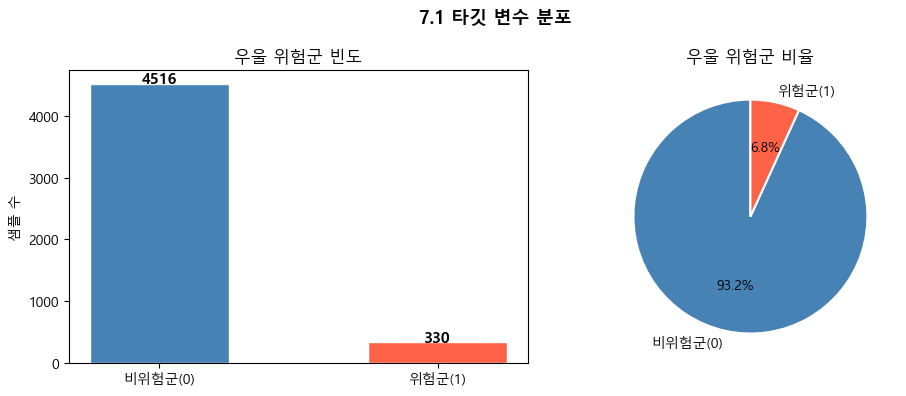

클래스 불균형 비율: 13.7:1  →  ⚠ 불균형 주의 (>5:1)

  7.2 연속형 변수 기술 통계
                   count   mean    std  min   50%    max  skewness  kurtosis
wkdy_sleep_hours  4838.0   6.75   1.29  3.0   7.0   14.0     -0.00      0.65
wknd_sleep_hours  4838.0   7.50   1.61  2.0   8.0   16.0      0.13      0.77
ear_noise_min      553.0  79.98  82.24  1.0  60.0  600.0      2.69     10.77
tinnitus_dist      356.0   3.72   2.60  0.0   3.0   10.0      0.37     -0.28 



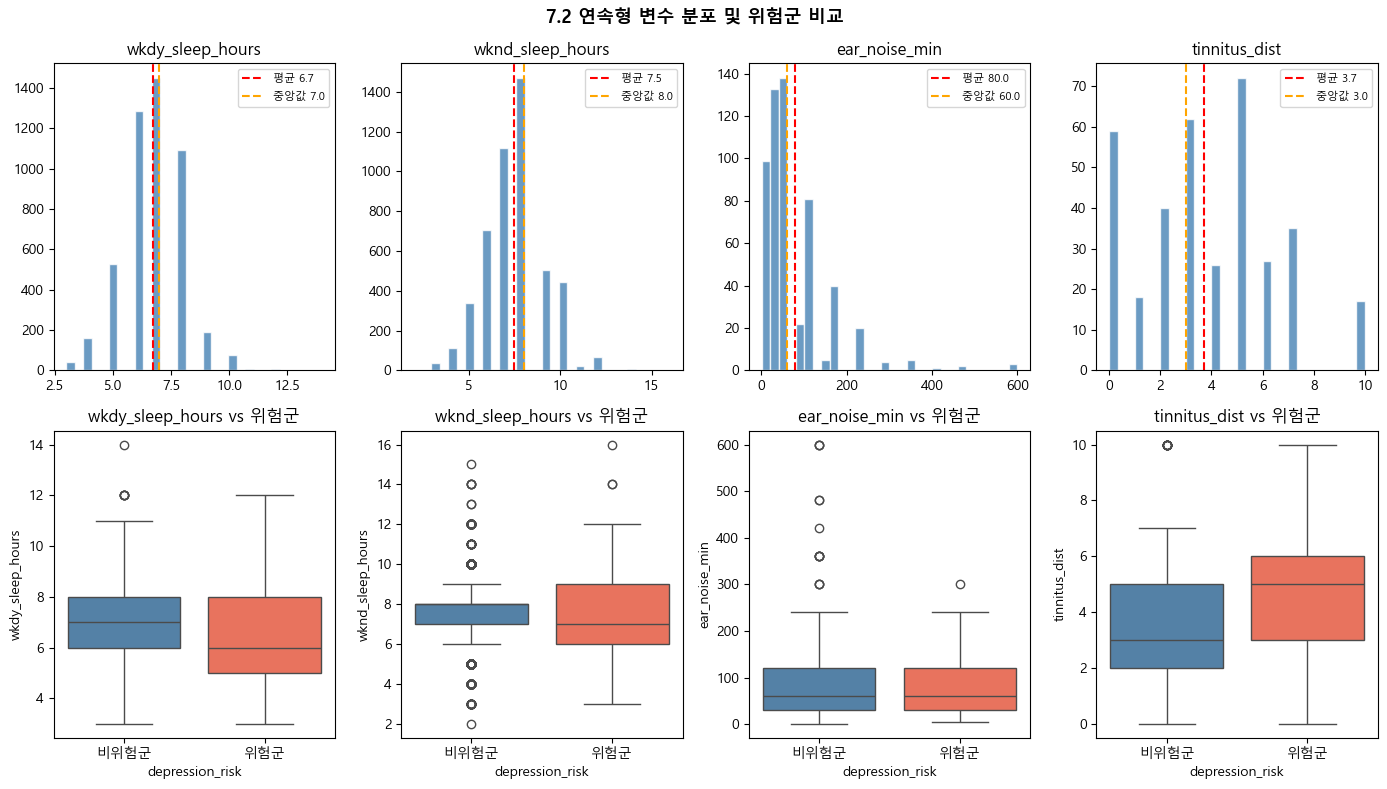

=== Mann-Whitney U 검정 (연속형 vs 위험군) ===
  wkdy_sleep_hours         : 비위험군 6.77 / 위험군 6.41  p=0.0000  ★ 유의
  wknd_sleep_hours         : 비위험군 7.51 / 위험군 7.33  p=0.0254  ★ 유의
  ear_noise_min            : 비위험군 80.00 / 위험군 79.77  p=0.7518  비유의
  tinnitus_dist            : 비위험군 3.61 / 위험군 4.90  p=0.0238  ★ 유의


In [13]:
import seaborn as sns
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
os.makedirs("figures", exist_ok=True)

TARGET    = "depression_risk"
CONT_COLS = ["wkdy_sleep_hours", "wknd_sleep_hours", "ear_noise_min", "tinnitus_dist"]
CAT_COLS  = [c for c in available_features if c not in CONT_COLS]
colors    = ["steelblue", "tomato"]

print("=" * 60)
print(f"  EDA  |  샘플: {len(df_model)}  |  변수: {len(available_features)}")
print("=" * 60)

# ── 7.1 타깃 변수 분포 ────────────────────────────────────────────
counts    = df_model[TARGET].value_counts().sort_index()
imbalance = counts[0] / counts[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["비위험군(0)", "위험군(1)"], counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("우울 위험군 빈도")
axes[0].set_ylabel("샘플 수")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].pie(counts.values, labels=["비위험군(0)", "위험군(1)"],
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("우울 위험군 비율")
plt.suptitle("7.1 타깃 변수 분포", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/01_target_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"클래스 불균형 비율: {imbalance:.1f}:1  →  {'⚠ 불균형 주의 (>5:1)' if imbalance > 5 else '허용 범위'}\n")

# ── 7.2 연속형 변수 단변량 분석 ──────────────────────────────────
valid_cont = [c for c in CONT_COLS if c in df_model.columns]
print("=" * 60)
print("  7.2 연속형 변수 기술 통계")
print("=" * 60)
desc = df_model[valid_cont].describe().T
desc["skewness"] = df_model[valid_cont].skew()
desc["kurtosis"] = df_model[valid_cont].kurt()
print(desc[["count", "mean", "std", "min", "50%", "max", "skewness", "kurtosis"]].round(2).to_string(), "\n")

fig, axes = plt.subplots(2, len(valid_cont), figsize=(14, 8))
for i, col in enumerate(valid_cont):
    data = df_model[col].dropna()
    axes[0][i].hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0][i].axvline(data.mean(),   color="red",    linestyle="--", label=f"평균 {data.mean():.1f}")
    axes[0][i].axvline(data.median(), color="orange", linestyle="--", label=f"중앙값 {data.median():.1f}")
    axes[0][i].set_title(col)
    axes[0][i].legend(fontsize=8)
    # palette를 dict 대신 리스트로 전달 (seaborn 최신 버전 호환)
    plot_df = df_model[[col, TARGET]].dropna().copy()
    plot_df[TARGET] = plot_df[TARGET].astype(str)
    sns.boxplot(data=plot_df, x=TARGET, y=col, ax=axes[1][i],
                order=["0", "1"], palette={"0": "steelblue", "1": "tomato"})
    axes[1][i].set_xticklabels(["비위험군", "위험군"])
    axes[1][i].set_title(f"{col} vs 위험군")
plt.suptitle("7.2 연속형 변수 분포 및 위험군 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_continuous.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Mann-Whitney U 검정 (연속형 vs 위험군) ===")
for col in valid_cont:
    g0 = df_model[df_model[TARGET] == 0][col].dropna()
    g1 = df_model[df_model[TARGET] == 1][col].dropna()
    if len(g0) > 0 and len(g1) > 0:
        _, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "★ 유의" if p < 0.05 else "비유의"
        print(f"  {col:<25}: 비위험군 {g0.mean():.2f} / 위험군 {g1.mean():.2f}  p={p:.4f}  {sig}")

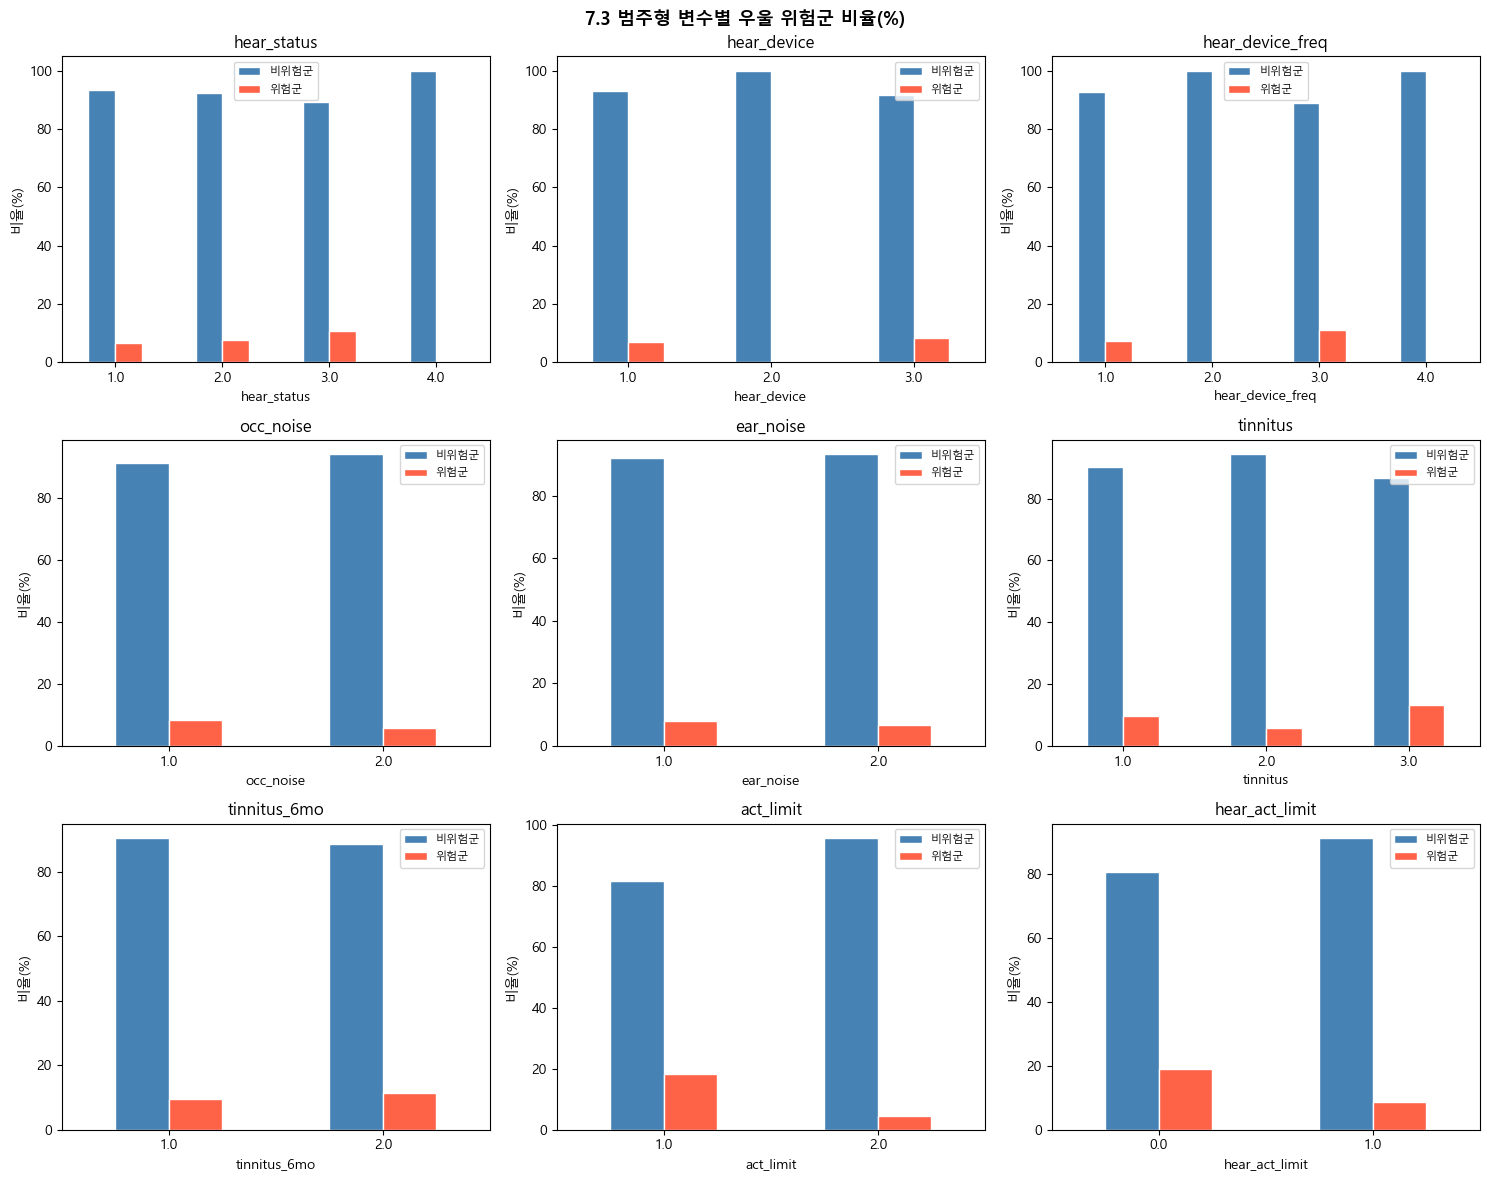

=== 카이제곱 검정 (범주형 vs 위험군) ===
  hear_status              : χ²=   3.96  p=0.2663  비유의
  hear_device              : χ²=   0.34  p=0.8455  비유의
  hear_device_freq         : χ²=   1.19  p=0.7553  비유의
  occ_noise                : χ²=   5.16  p=0.0231  ★ 유의
  ear_noise                : χ²=   0.96  p=0.3281  비유의
  tinnitus                 : χ²=  11.59  p=0.0030  ★ 유의
  tinnitus_6mo             : χ²=   0.07  p=0.7941  비유의
  act_limit                : χ²= 208.80  p=0.0000  ★ 유의
  hear_act_limit           : χ²=   3.27  p=0.0706  비유의


In [14]:
# ── 7.3 범주형 변수 분석 + 카이제곱 검정 ────────────────────────
valid_cat = [c for c in CAT_COLS if c in df_model.columns]
n_cols = 3
n_rows = -(-len(valid_cat) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(valid_cat):
    ct = pd.crosstab(df_model[col], df_model[TARGET], normalize="index") * 100
    ct.columns = ["비위험군", "위험군"]
    ct.plot(kind="bar", ax=axes[i], color=colors, rot=0, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("비율(%)")
    axes[i].legend(fontsize=8)
for j in range(len(valid_cat), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("7.3 범주형 변수별 우울 위험군 비율(%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== 카이제곱 검정 (범주형 vs 위험군) ===")
for col in valid_cat:
    ct = pd.crosstab(df_model[col], df_model[TARGET])
    if ct.shape[1] < 2:
        continue
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = "★ 유의" if p < 0.05 else "비유의"
    print(f"  {col:<25}: χ²={chi2:>7.2f}  p={p:.4f}  {sig}")

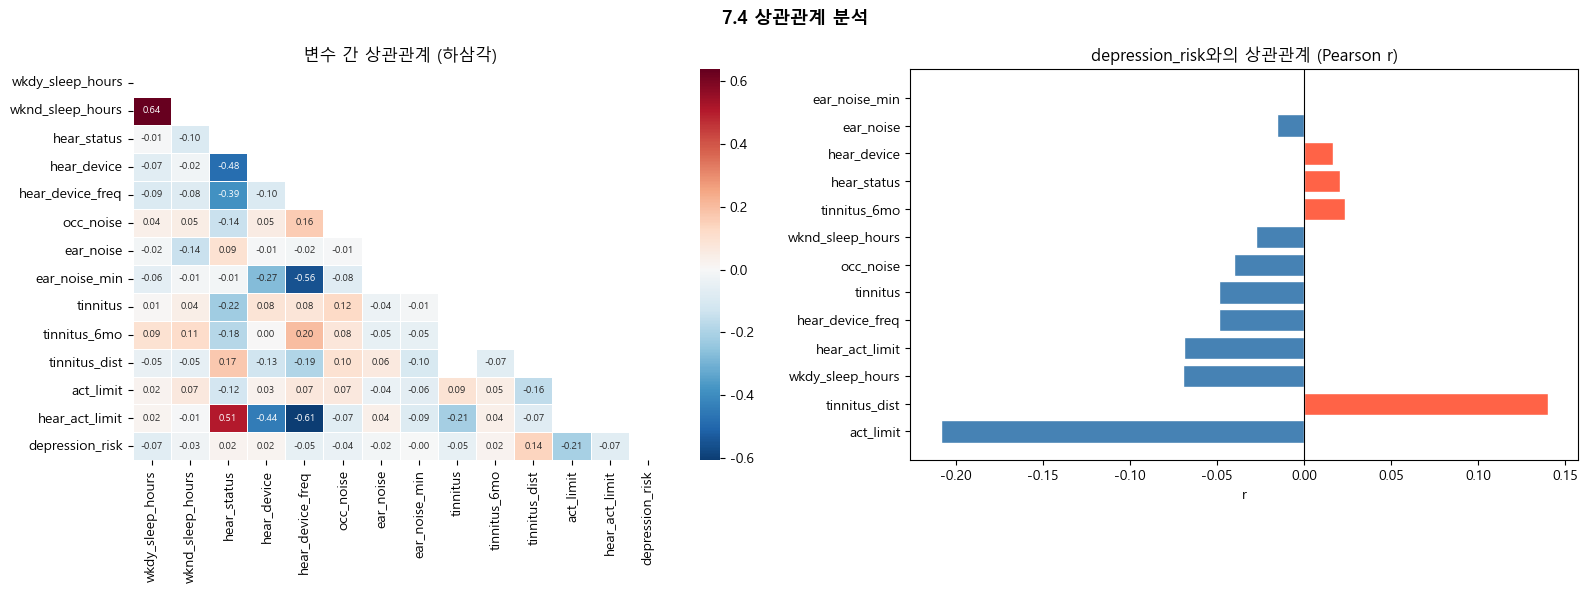

=== 타깃과 상관관계 TOP 5 ===
act_limit          -0.209
tinnitus_dist       0.140
wkdy_sleep_hours   -0.070
hear_act_limit     -0.069
hear_device_freq   -0.049


In [15]:
# ── 7.4 상관관계 분석 ────────────────────────────────────────────
corr_cols = available_features + [TARGET]
corr = df_model[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, annot_kws={"size": 7})
axes[0].set_title("변수 간 상관관계 (하삼각)")

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
bar_colors  = ["tomato" if v > 0 else "steelblue" for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("depression_risk와의 상관관계 (Pearson r)")
axes[1].set_xlabel("r")
plt.suptitle("7.4 상관관계 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== 타깃과 상관관계 TOP 5 ===")
print(target_corr.head(5).round(3).to_string())

  7.5 이상치 탐지 (IQR 1.5 기준, 연속형 변수)
  wkdy_sleep_hours         : 정상 범위 [3.0, 11.0]  →  이상치 8개 (0.2%)
  wknd_sleep_hours         : 정상 범위 [5.5, 9.5]  →  이상치 1034개 (21.3%)
  ear_noise_min            : 정상 범위 [-105.0, 255.0]  →  이상치 15개 (0.3%)
  tinnitus_dist            : 정상 범위 [-2.5, 9.5]  →  이상치 17개 (0.4%)

  7.6 결측치 분석
                  결측 수       결측률
hear_device_freq  4771  0.984523
tinnitus_dist     4490  0.926537
tinnitus_6mo      4450  0.918283
ear_noise_min     4293  0.885885
hear_device       4198  0.866281
hear_act_limit    4012  0.827899
occ_noise         1389  0.286628
tinnitus          1389  0.286628
hear_status        267  0.055097
ear_noise          267  0.055097
wkdy_sleep_hours     8  0.001651
wknd_sleep_hours     8  0.001651
act_limit            3  0.000619 



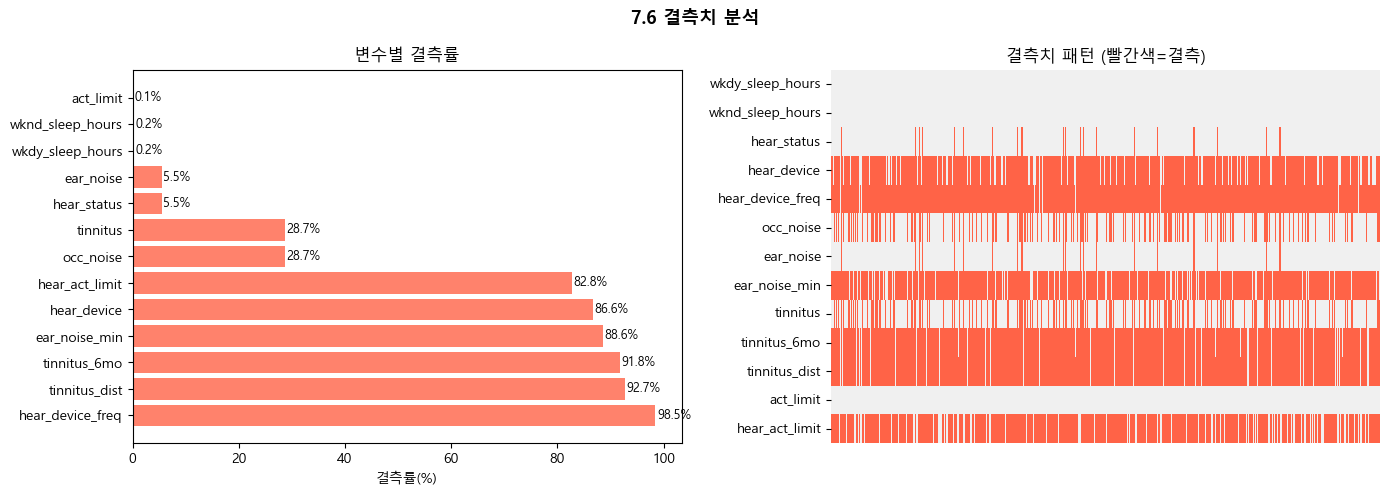

  EDA 요약
1. 클래스 불균형  : 13.7:1  → 모델링 시 stratify / class_weight 적용 권장
2. 수면시간       : 위험군이 더 짧은 경향 (Mann-Whitney 검정 확인)
3. 결측치 최다    : hear_device_freq (98.5%) → 파이프라인 내 imputer로 처리
4. 타깃 상관 1위  : act_limit (r=-0.209)
5. 이상치 최다    : wknd_sleep_hours (21.3%) → 파이프라인 내 처리 또는 클리핑 검토


In [16]:
# ── 7.5 이상치 탐지 (IQR) ────────────────────────────────────────
print("=" * 60)
print("  7.5 이상치 탐지 (IQR 1.5 기준, 연속형 변수)")
print("=" * 60)
outlier_info = {}
for col in valid_cont:
    q1, q3 = df_model[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_model[col] < lo) | (df_model[col] > hi)).sum()
    outlier_info[col] = {"lower": lo, "upper": hi, "n": n_out, "rate": n_out / len(df_model)}
    print(f"  {col:<25}: 정상 범위 [{lo:.1f}, {hi:.1f}]  →  이상치 {n_out}개 ({n_out/len(df_model):.1%})")

# ── 7.6 결측치 분석 ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("  7.6 결측치 분석")
print("=" * 60)
missing = df_model[available_features].isna().mean().sort_values(ascending=False)
miss_df = df_model[available_features].isna().sum().sort_values(ascending=False).to_frame("결측 수")
miss_df["결측률"] = missing
print(miss_df.to_string(), "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_nz = missing[missing > 0]
if len(missing_nz) > 0:
    axes[0].barh(missing_nz.index, missing_nz.values * 100, color="tomato", alpha=0.8)
    axes[0].set_xlabel("결측률(%)")
    axes[0].set_title("변수별 결측률")
    for i, v in enumerate(missing_nz.values):
        axes[0].text(v * 100 + 0.3, i, f"{v:.1%}", va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "결측치 없음", ha="center", transform=axes[0].transAxes)
sns.heatmap(df_model[available_features].isna().T, cbar=False,
            cmap=["#f0f0f0", "tomato"], ax=axes[1],
            yticklabels=True, xticklabels=False)
axes[1].set_title("결측치 패턴 (빨간색=결측)")
plt.suptitle("7.6 결측치 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/05_missing.png", dpi=150, bbox_inches="tight")
plt.show()

# ── EDA 요약 ────────────────────────────────────────────────────
top_out = max(outlier_info, key=lambda x: outlier_info[x]["rate"]) if outlier_info else "N/A"
print("=" * 60)
print("  EDA 요약")
print("=" * 60)
print(f"1. 클래스 불균형  : {imbalance:.1f}:1  → 모델링 시 stratify / class_weight 적용 권장")
print(f"2. 수면시간       : 위험군이 더 짧은 경향 (Mann-Whitney 검정 확인)")
print(f"3. 결측치 최다    : {missing.index[0]} ({missing.iloc[0]:.1%}) → 파이프라인 내 imputer로 처리")
print(f"4. 타깃 상관 1위  : {target_corr.index[0]} (r={target_corr.iloc[0]:.3f})")
if top_out != "N/A":
    print(f"5. 이상치 최다    : {top_out} ({outlier_info[top_out]['rate']:.1%}) → 파이프라인 내 처리 또는 클리핑 검토")

---

# 8. Train/Test Split 및 전처리 파이프라인

## 클래스 불균형 처리 전략

EDA 결과 비위험군 : 위험군 = **13.7 : 1**의 심각한 클래스 불균형이 확인됐다.
다음 두 가지 방법을 적용한다.

| 방법 | 적용 위치 | 효과 |
|------|-----------|------|
| `stratify=y` | `train_test_split` | 분할 후에도 클래스 비율 유지 |
| `class_weight='balanced'` | 분류 모델 초기화 | 소수 클래스(위험군)에 역비율 가중치 부여 |

결측치 대체, 인코딩, 스케일링은 train/test split 이후 파이프라인 내부에서 수행한다 (데이터 누수 방지).

In [17]:
# 원본 설문 변수는 제거하고, 의미 중심으로 재코딩한 파생변수만 사용
drop_from_X = [
    c for c in [
        "id",
        "depression_risk",
        "hear_device",
        "hear_device_freq",
        "occ_noise",
        "ear_noise",
        "ear_noise_min",
        "tinnitus",
        "tinnitus_6mo",
        "tinnitus_dist",
        "act_limit",
        "hear_act_limit"
    ]
    if c in df_model.columns
]

X = df_model.drop(columns=drop_from_X)
y = df_model["depression_risk"]

if y.nunique() < 2:
    raise ValueError("타깃 클래스가 하나뿐입니다. depression_risk 생성 기준을 확인하세요.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("\nTrain target ratio")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest target ratio")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (3876, 19)   X_test: (970, 19)

Train target ratio
depression_risk
0    0.931889
1    0.068111
Name: proportion, dtype: float64

Test target ratio
depression_risk
0    0.931959
1    0.068041
Name: proportion, dtype: float64


In [18]:
# 수치형/이진형 변수
numeric_features = [c for c in [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_diff",
    "sleep_short",
    "sleep_long",
    "sleep_catchup_large",

    "hear_device_use",
    "hear_device_freq_ord",
    "hear_device_freq_unknown",

    "occ_noise_yes",
    "ear_noise_use",
    "ear_noise_min_clean",
    "ear_noise_min_missing",

    "tinnitus_use",
    "tinnitus_6mo_yes",
    "tinnitus_dist_score",

    "act_limit_yes",
    "hear_act_limit_yes",
] if c in X.columns]

# 남은 변수 중 범주형으로 처리할 변수
# hear_status는 본인 청력 상태라서 원핫인코딩으로 처리해도 무난
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['wkdy_sleep_hours', 'wknd_sleep_hours', 'sleep_diff', 'sleep_short', 'sleep_long', 'sleep_catchup_large', 'hear_device_use', 'hear_device_freq_ord', 'hear_device_freq_unknown', 'occ_noise_yes', 'ear_noise_use', 'ear_noise_min_clean', 'ear_noise_min_missing', 'tinnitus_use', 'tinnitus_6mo_yes', 'tinnitus_dist_score', 'act_limit_yes', 'hear_act_limit_yes']
범주형 변수: ['hear_status']


---

# 9. 모델 학습

동일한 전처리 파이프라인을 사용하여 여러 분류 모델의 성능을 비교한다.

In [ ]:
# class_weight='balanced': 클래스 불균형(13.7:1) 대응 — 소수 클래스에 역비율 가중치 부여
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        # class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        # class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        # class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} 학습 완료")

Logistic Regression 학습 완료
Random Forest 학습 완료
Hist Gradient Boosting 학습 완료


In [48]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Logistic Regression + UnderSampling": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Logistic Regression + UnderSampling": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Random Forest + UnderSampling": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Hist Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ])
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} 학습 완료")

Logistic Regression 학습 완료
Logistic Regression + UnderSampling 학습 완료
Random Forest 학습 완료
Random Forest + UnderSampling 학습 완료
Hist Gradient Boosting 학습 완료


---

# 10. 성능 평가

우울 위험군은 소수 클래스일 가능성이 있으므로 Accuracy만으로 성능을 판단하지 않고 Recall, F1-score, ROC-AUC를 함께 확인한다.

In [49]:
from sklearn.metrics import average_precision_score

def get_positive_score(pipe, X_data):
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        return pipe.predict_proba(X_data)[:, 1]
    if hasattr(pipe.named_steps["model"], "decision_function"):
        return pipe.decision_function(X_data)
    return pipe.predict(X_data)

results = []
for name, pipe in pipelines.items():
    y_pred  = pipe.predict(X_test)
    y_score = get_positive_score(pipe, X_test)
    results.append({
        "model":     name,
        "ROC-AUC":   roc_auc_score(y_test, y_score),
        "PR-AUC":    average_precision_score(y_test, y_score),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "Accuracy":  accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("=== 모델 성능 비교 (정렬 기준: ROC-AUC) ===")
print("※ 클래스 불균형 환경에서 Accuracy보다 ROC-AUC / PR-AUC / F1 중심으로 해석")
display(results_df)

=== 모델 성능 비교 (정렬 기준: ROC-AUC) ===
※ 클래스 불균형 환경에서 Accuracy보다 ROC-AUC / PR-AUC / F1 중심으로 해석


,model,ROC-AUC,PR-AUC,F1,Precision,Recall,Accuracy
0,Logistic Regression,0.729007,0.213392,0.245399,0.153846,0.606061,0.746392
1,Logistic Regression + UnderSampling,0.681860,0.198573,0.231003,0.144487,0.575758,0.739175
3,Random Forest + UnderSampling,0.679044,0.144896,0.216524,0.133333,0.575758,0.716495
4,Hist Gradient Boosting,0.644970,0.156757,0.054795,0.285714,0.030303,0.928866
2,Random Forest,0.587364,0.118005,0.177778,0.125786,0.303030,0.809278


In [47]:
## 10.1 Logistic Regression Threshold 조정

# 기본 threshold 0.5 대신 여러 threshold를 비교하여 클래스 불균형 상황에서 Precision, Recall, F1-score의 변화를 확인한다.

# ============================================================
# 10.1 Logistic Regression Threshold 조정
# - 기본 threshold=0.5 대신 여러 threshold를 비교
# - 클래스 불균형 상황에서 Precision, Recall, F1-score 균형 확인
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

log_pipe = pipelines["Logistic Regression + UnderSampling"]

# Logistic Regression의 우울 위험군(1) 예측 확률
y_proba_log = log_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for th in thresholds:
    y_pred_th = (y_proba_log >= th).astype(int)

    threshold_results.append({
        "threshold": round(th, 2),
        "ROC-AUC":   roc_auc_score(y_test, y_score),
        "precision": precision_score(y_test, y_pred_th, zero_division=0),
        "recall": recall_score(y_test, y_pred_th, zero_division=0),
        "f1": f1_score(y_test, y_pred_th, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_th),
        "predicted_positive": y_pred_th.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

print("=== Logistic Regression Threshold별 성능 비교 ===")
display(threshold_df.sort_values("f1", ascending=False))

=== Logistic Regression Threshold별 성능 비교 ===


,threshold,ROC-AUC,precision,recall,f1,accuracy,predicted_positive
11,0.65,0.64497,0.226415,0.363636,0.279070,0.872165,106
10,0.60,0.64497,0.181818,0.484848,0.264463,0.816495,176
12,0.70,0.64497,0.312500,0.227273,0.263158,0.913402,48
9,0.55,0.64497,0.160870,0.560606,0.250000,0.771134,230
7,0.45,0.64497,0.141892,0.636364,0.232044,0.713402,296
8,0.50,0.64497,0.144487,0.575758,0.231003,0.739175,263
13,0.75,0.64497,0.343750,0.166667,0.224490,0.921649,32
6,0.40,0.64497,0.117978,0.636364,0.199052,0.651546,356
14,0.80,0.64497,0.421053,0.121212,0.188235,0.928866,19
5,0.35,0.64497,0.078582,0.772727,0.142657,0.368041,649


In [41]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


=== F1-score 기준 최적 threshold ===


threshold              0.700000
precision              0.271739
recall                 0.378788
f1                     0.316456
accuracy               0.888660
predicted_positive    92.000000
Name: 12, dtype: float64


Best threshold: 0.7
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       904
           1       0.27      0.38      0.32        66

    accuracy                           0.89       970
   macro avg       0.61      0.65      0.63       970
weighted avg       0.91      0.89      0.90       970



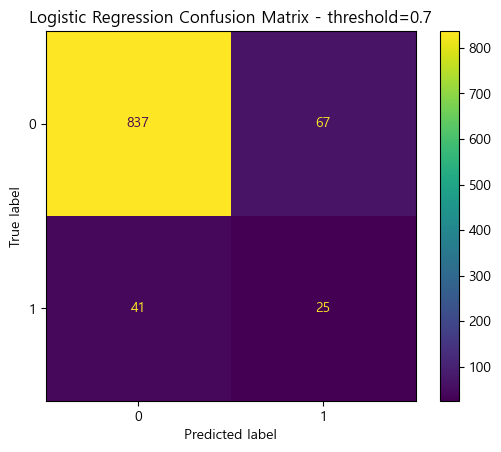

In [22]:
# F1-score가 가장 높은 threshold 선택
best_threshold_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_threshold_row["threshold"]

print("=== F1-score 기준 최적 threshold ===")
display(best_threshold_row)

# 최적 threshold 적용
y_pred_log_best = (y_proba_log >= best_threshold).astype(int)

print(f"\nBest threshold: {best_threshold}")
print(classification_report(y_test, y_pred_log_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_log_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Logistic Regression Confusion Matrix - threshold={best_threshold}")
plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.76      0.85       904
           1       0.15      0.61      0.25        66

    accuracy                           0.75       970
   macro avg       0.56      0.68      0.55       970
weighted avg       0.91      0.75      0.81       970



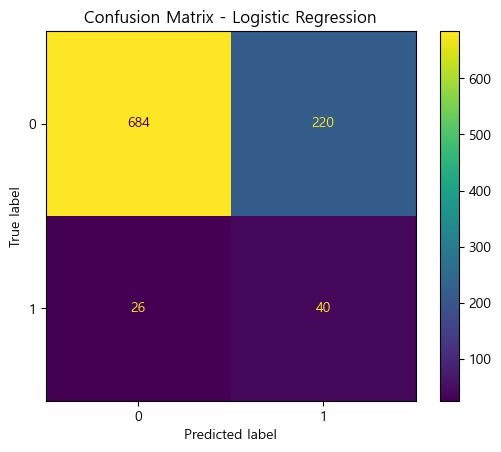

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       904
           1       0.13      0.30      0.18        66

    accuracy                           0.81       970
   macro avg       0.53      0.57      0.53       970
weighted avg       0.89      0.81      0.84       970



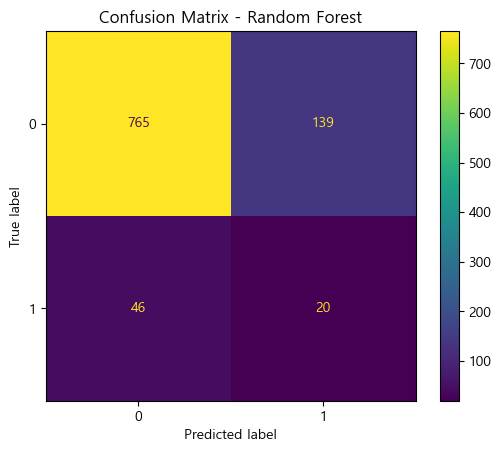

Hist Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       904
           1       0.13      0.44      0.20        66

    accuracy                           0.76       970
   macro avg       0.54      0.61      0.53       970
weighted avg       0.89      0.76      0.82       970



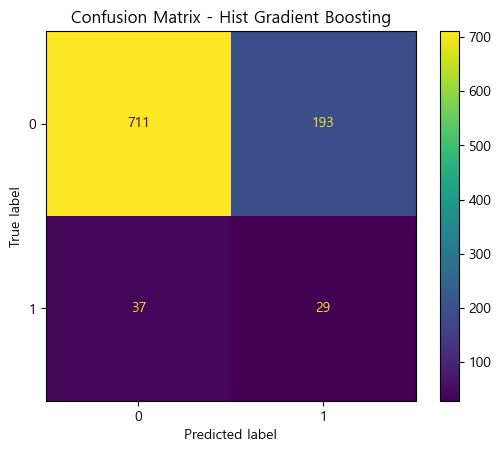

In [23]:
# 모델별 Classification Report 및 Confusion Matrix
for name, pipe in pipelines.items():
    print("=" * 80)
    print(name)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

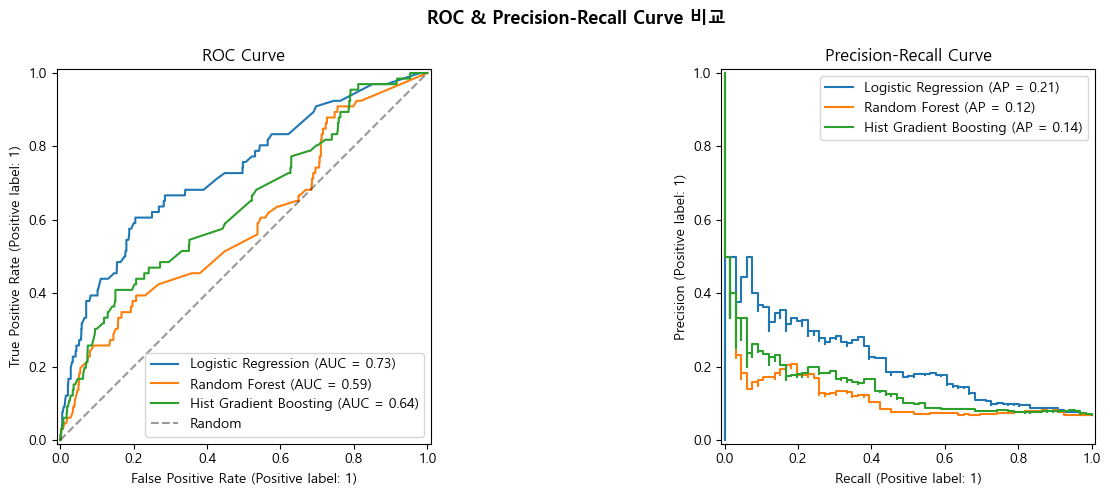

In [24]:
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
axes[0].set_title("ROC Curve")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].legend()

for name, pipe in pipelines.items():
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.suptitle("ROC & Precision-Recall Curve 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/06_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---

# 11. 변수 중요도 및 해석

Random Forest 또는 Gradient Boosting 계열 모델의 중요도를 확인한다. One-Hot Encoding 이후 변수명이 확장되므로, 전처리 후 feature name을 확인하여 해석한다.

,feature,importance
16,act_limit_yes,0.209936
0,wkdy_sleep_hours,0.132743
1,wknd_sleep_hours,0.126512
2,sleep_diff,0.101650
11,ear_noise_min_clean,0.098442
9,occ_noise_yes,0.050512
15,tinnitus_dist_score,0.047389
3,sleep_short,0.045363
18,hear_status_1.0,0.025005
10,ear_noise_use,0.024850


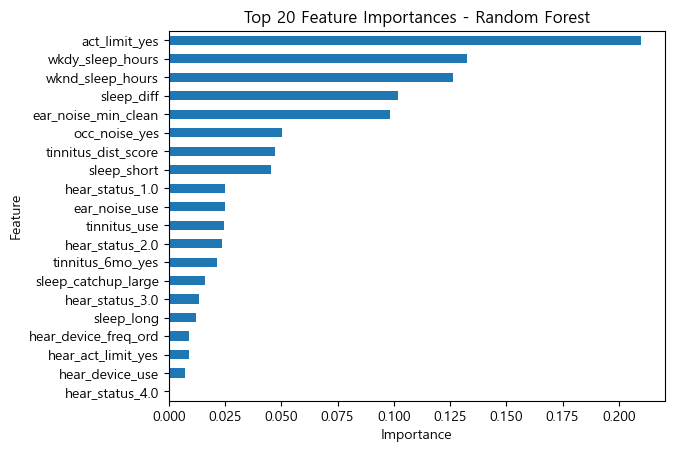

In [25]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_features)

    if "cat" in preprocessor.named_transformers_ and categorical_features:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features)
        feature_names.extend(cat_names)

    return np.array(feature_names)

rf_pipe = pipelines["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(rf_pipe.named_steps["preprocessor"])

if hasattr(rf_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    importances.head(20).sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
    )
    plt.title("Top 20 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

Permutation importance model: Logistic Regression


,feature,importance_mean,importance_std
13,act_limit_yes,0.184460,0.014876
15,sleep_short,0.008874,0.008138
1,wknd_sleep_hours,0.008838,0.003991
16,sleep_long,0.006474,0.006006
7,ear_noise_use,0.005146,0.005070
2,hear_status,0.004150,0.002484
6,occ_noise_yes,0.003219,0.003533
3,hear_device_use,0.002913,0.004283
0,wkdy_sleep_hours,0.002593,0.002829
10,tinnitus_use,0.002078,0.002544


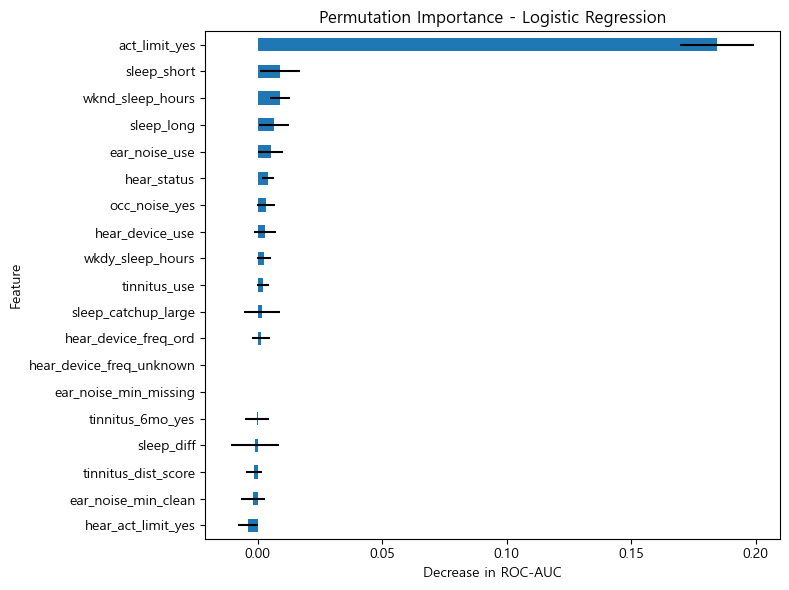

In [26]:
# ============================================================
# 11.1 XAI ① Permutation Importance
# - 기존 feature_importances_보다 해석이 더 안정적
# - 원본 변수 단위로 중요도 확인 가능
# ============================================================

from sklearn.inspection import permutation_importance

best_model_name = results_df.iloc[0]["model"]
best_pipe = pipelines[best_model_name]

print(f"Permutation importance model: {best_model_name}")

perm_result = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    # n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance)

ax = perm_importance.sort_values("importance_mean").plot(
    kind="barh",
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    legend=False,
    figsize=(8, 6)
)
ax.set_title(f"Permutation Importance - {best_model_name}")
ax.set_xlabel("Decrease in ROC-AUC")
ax.set_ylabel("Feature")
plt.tight_layout()

In [27]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [28]:
# ============================================================
# 11.2 XAI ② SHAP 적용 준비
# - Random Forest 기준 SHAP 분석
# - 파이프라인 내부 전처리 후 데이터를 SHAP에 넣어야 함
# ============================================================

# Colab에서 shap이 설치되어 있지 않으면 아래 줄 실행
# !pip install shap -q

import shap

# Random Forest 모델 기준
rf_pipe = pipelines["Random Forest"]
rf_preprocessor = rf_pipe.named_steps["preprocessor"]
rf_model = rf_pipe.named_steps["model"]

# 전처리된 train/test 데이터 생성
X_train_transformed = rf_preprocessor.transform(X_train)
X_test_transformed = rf_preprocessor.transform(X_test)

# sparse matrix일 경우 dense array로 변환
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# 전처리 후 feature name 가져오기
feature_names = get_feature_names_from_preprocessor(rf_preprocessor)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

print("SHAP 분석용 데이터 크기:", X_test_shap.shape)
X_test_shap.head()

SHAP 분석용 데이터 크기: (970, 22)


,wkdy_sleep_hours,wknd_sleep_hours,sleep_diff,sleep_short,sleep_long,sleep_catchup_large,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes,hear_status_1.0,hear_status_2.0,hear_status_3.0,hear_status_4.0
4476,0.216094,1.566661,1.792717,-0.433853,-0.239339,1.865724,-0.124327,-0.105425,0.0,-0.36242,-0.355091,-0.247566,0.0,-0.286396,-0.264257,-0.22846,-0.458796,-0.111979,1.0,0.0,0.0,0.0
2082,0.216094,-0.282982,-0.585302,-0.433853,-0.239339,-0.535985,-0.124327,-0.105425,0.0,-0.36242,-0.355091,-0.247566,0.0,-0.286396,-0.264257,-0.22846,-0.458796,-0.111979,1.0,0.0,0.0,0.0
1587,1.757179,1.566661,0.207371,-0.433853,4.178175,-0.535985,-0.124327,-0.105425,0.0,-0.36242,2.816181,0.589045,0.0,-0.286396,-0.264257,-0.22846,-0.458796,-0.111979,1.0,0.0,0.0,0.0
5154,0.986636,1.566661,1.000044,-0.433853,-0.239339,1.865724,-0.124327,-0.105425,0.0,-0.36242,-0.355091,-0.247566,0.0,-0.286396,-0.264257,-0.22846,-0.458796,-0.111979,1.0,0.0,0.0,0.0
5859,-0.554449,-0.899530,-0.585302,-0.433853,-0.239339,-0.535985,-0.124327,-0.105425,0.0,-0.36242,-0.355091,-0.247566,0.0,-0.286396,-0.264257,-0.22846,-0.458796,-0.111979,1.0,0.0,0.0,0.0


In [29]:
# ============================================================
# 11.3 XAI ③ SHAP 값 계산
# - 데이터가 크면 시간이 오래 걸릴 수 있어서 일부 샘플만 사용
# ============================================================

# SHAP 계산 속도 조절용 샘플링
# 너무 오래 걸리면 300, 500 정도로 줄이면 됨
shap_sample_size = min(1000, len(X_test_shap))

X_shap_sample = X_test_shap.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

# binary classification에서는 클래스별 SHAP 값이 나올 수 있음
# 우울 위험군(1)에 대한 SHAP 값을 사용
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    # shap 버전에 따라 3차원 배열로 나오는 경우 처리
    if len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

print("SHAP values shape:", shap_values_class1.shape)

SHAP values shape: (970, 22)


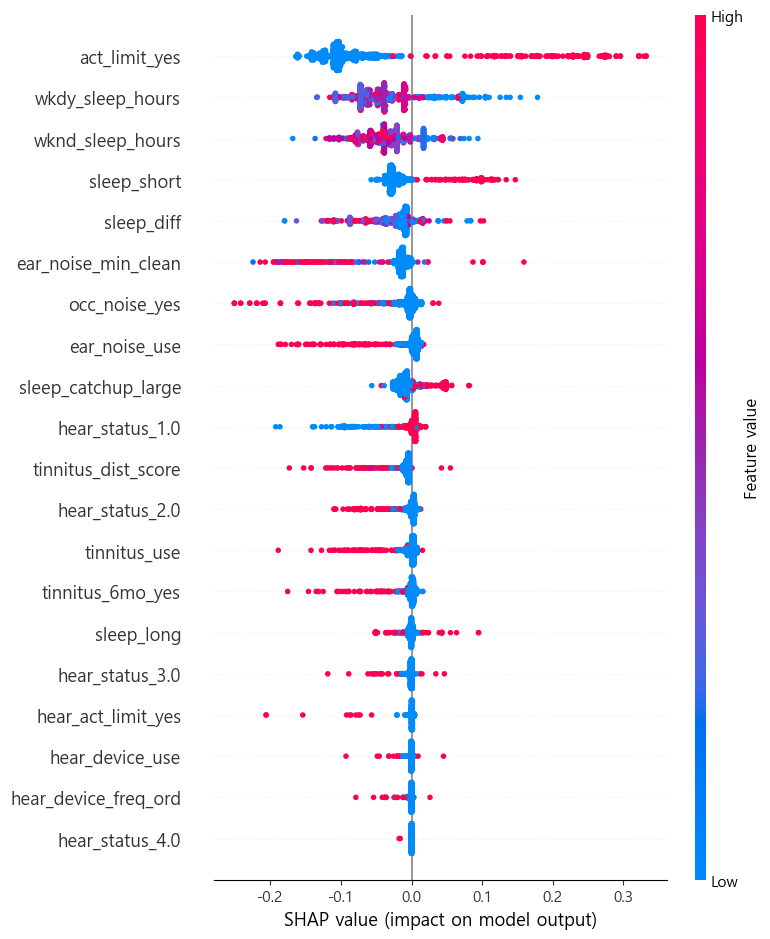

In [30]:
# ============================================================
# 11.4 XAI ④ SHAP Summary Plot
# - 변수별 영향력과 방향성을 동시에 확인
# - 오른쪽으로 갈수록 우울 위험군(1) 예측을 높이는 방향
# ============================================================

shap.summary_plot(
    shap_values_class1,
    X_shap_sample,
    plot_type="dot",
    max_display=20
)

,original_feature,mean_abs_shap
0,act_limit_yes,0.115682
1,wkdy_sleep_hours,0.051112
2,wknd_sleep_hours,0.041043
3,sleep_short,0.031944
4,sleep_diff,0.028137
5,ear_noise_min_clean,0.025680
6,hear_status,0.024389
7,occ_noise_yes,0.017641
8,ear_noise_use,0.015597
9,sleep_catchup_large,0.013574


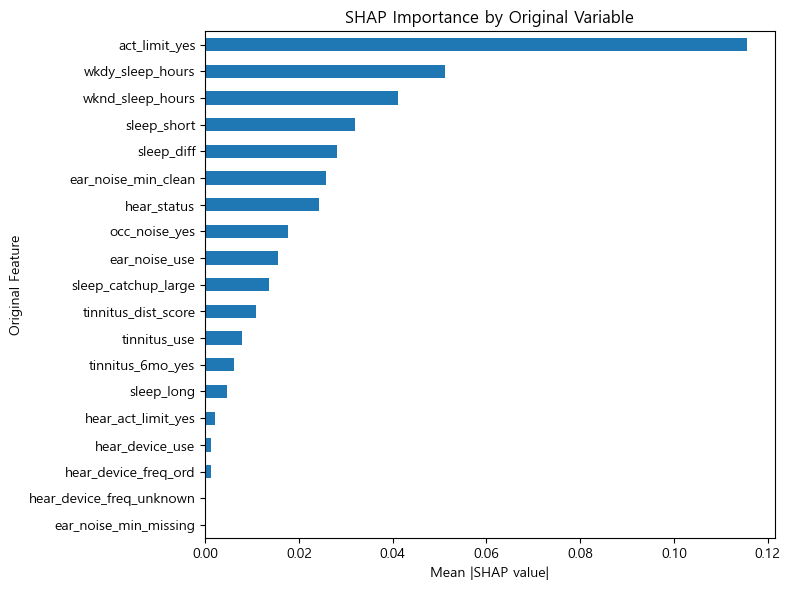

In [31]:
# ============================================================
# 11.6 XAI ⑥ 원래 변수 단위로 SHAP 중요도 묶기
# - One-Hot Encoding으로 쪼개진 범주형 변수를 원래 변수명으로 합산
# ============================================================

shap_importance = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

def map_original_feature_from_encoded(encoded_name):
    for col in categorical_features:
        if encoded_name.startswith(col + "_"):
            return col
    return encoded_name

shap_importance["original_feature"] = shap_importance["feature"].apply(
    map_original_feature_from_encoded
)

original_shap_importance = (
    shap_importance
    .groupby("original_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(original_shap_importance)

original_shap_importance.sort_values("mean_abs_shap").plot(
    kind="barh",
    x="original_feature",
    y="mean_abs_shap",
    legend=False,
    figsize=(8, 6)
)

plt.title("SHAP Importance by Original Variable")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

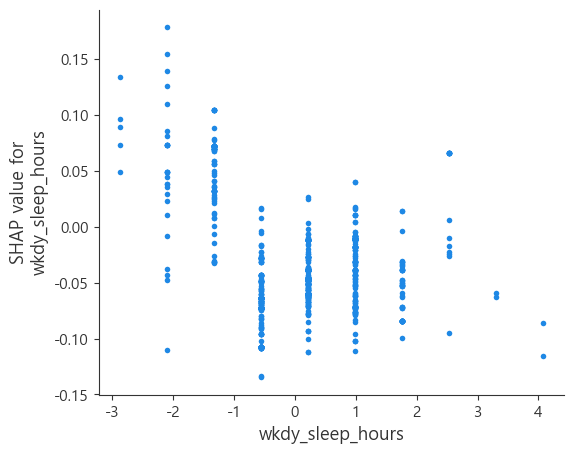

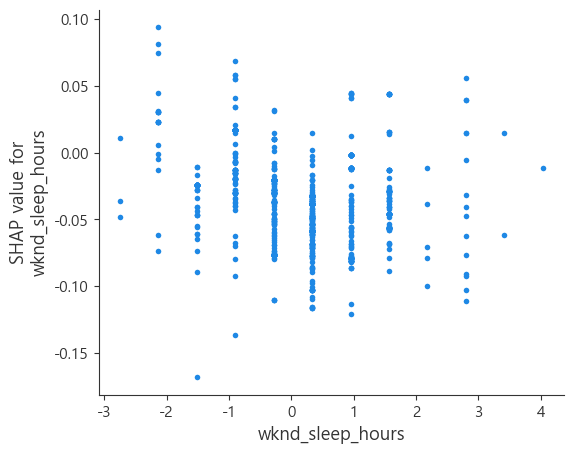

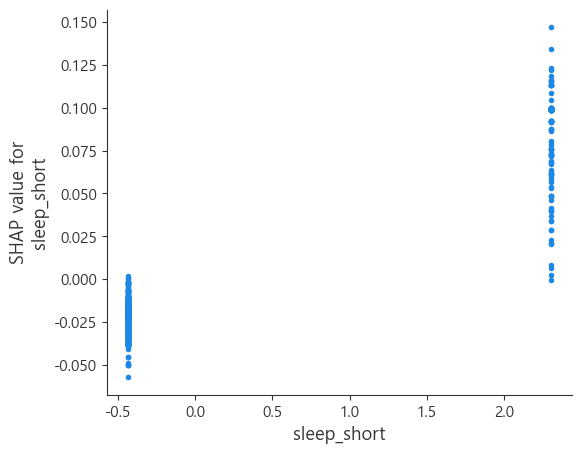

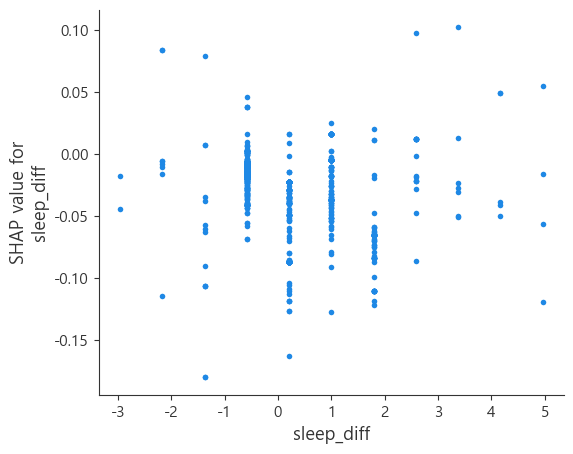

In [32]:
# ============================================================
# 11.7 XAI ⑦ 수면시간 변수의 방향성 확인
# - 수면시간이 길수록/짧을수록 우울 위험 예측에 어떤 영향을 주는지 확인
# ============================================================

sleep_features_to_check = [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_short",
    "sleep_diff"
]

for feature in sleep_features_to_check:
    if feature in X_shap_sample.columns:
        shap.dependence_plot(
            feature,
            shap_values_class1,
            X_shap_sample,
            interaction_index=None
        )

In [33]:
# ============================================================
# 우울 위험군으로 예측된 사람 목록 확인
# ============================================================

# Random Forest 기준 예측
y_pred = rf_pipe.predict(X_test)
y_pred_proba = rf_pipe.predict_proba(X_test)[:, 1]

pred_result = X_test.copy()
pred_result["actual"] = y_test.values
pred_result["predicted"] = y_pred
pred_result["pred_proba_depression"] = y_pred_proba

# X_test 안에서의 순서 번호 추가
pred_result["test_order"] = range(len(pred_result))

# 원본 데이터프레임에서의 index도 보존
pred_result["original_index"] = pred_result.index

# 우울 위험군으로 예측된 사람만 보기
depression_predicted = pred_result[pred_result["predicted"] == 1].sort_values(
    "pred_proba_depression",
    ascending=False
)

display(depression_predicted)

,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes,sleep_short,sleep_long,sleep_diff,sleep_catchup_large,actual,predicted,pred_proba_depression,test_order,original_index
4757,7.0,9.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,2.0,1,1,1,0.905962,404,4757
245,7.0,9.0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,1.0,0.0,0,0,2.0,1,0,1,0.905962,47,245
509,4.0,7.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,3.0,1,0,1,0.902323,866,509
5182,5.0,7.0,1.0,NaN,NaN,0,NaN,0.0,0.0,0,NaN,NaN,NaN,1.0,0.0,1,0,2.0,1,1,1,0.872902,547,5182
5218,5.0,7.0,1.0,NaN,NaN,0,NaN,0.0,0.0,0,NaN,NaN,NaN,1.0,0.0,1,0,2.0,1,0,1,0.872902,13,5218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4856,5.0,6.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,1.0,0,0,1,0.527834,834,4856
2820,5.0,6.0,1.0,NaN,NaN,0,NaN,0.0,0.0,0,NaN,NaN,NaN,0.0,0.0,1,0,1.0,0,1,1,0.527834,535,2820
1312,5.0,6.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,1.0,0,0,1,0.527834,150,1312
5738,4.0,4.0,1.0,NaN,NaN,0,1.0,0.0,0.0,0,1.0,1.0,10.0,0.0,0.0,1,0,0.0,0,0,1,0.527213,398,5738


In [34]:
# ============================================================
# 11.8 XAI ⑧ 개별 사례 해석
# - 특정 사람 1명의 예측이 왜 우울 위험군으로 나왔는지 확인
# ============================================================

# 특정 한 사람 선정
sample_idx = 47   # test order 값을 입력

print("실제값:", y_test.iloc[sample_idx])
print("예측값:", rf_pipe.predict(X_test.iloc[[sample_idx]])[0])
print("우울 위험군 예측확률:", rf_pipe.predict_proba(X_test.iloc[[sample_idx]])[0, 1])

# force plot은 노트북 환경에서 JS 초기화 필요
shap.initjs()

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_values_class1[sample_idx],
    X_shap_sample.iloc[sample_idx]
)

실제값: 0
예측값: 1
우울 위험군 예측확률: 0.9059622969645208


,original_feature,importance
0,act_limit_yes,0.209936
1,wkdy_sleep_hours,0.132743
2,wknd_sleep_hours,0.126512
3,sleep_diff,0.101650
4,ear_noise_min_clean,0.098442
5,hear_status,0.062711
6,occ_noise_yes,0.050512
7,tinnitus_dist_score,0.047389
8,sleep_short,0.045363
9,ear_noise_use,0.024850


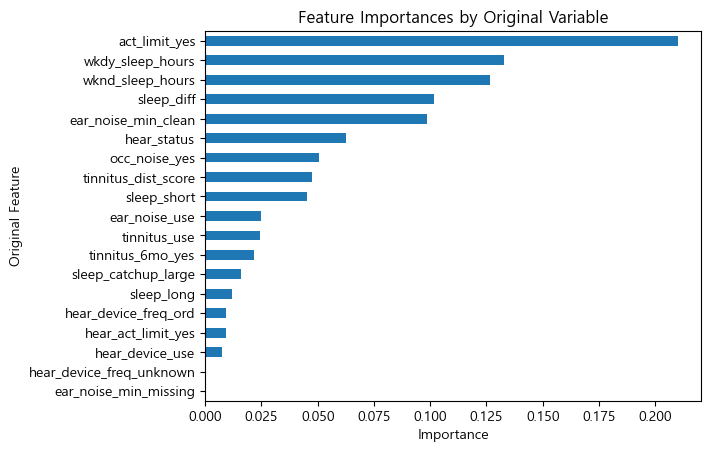

In [35]:
# 원래 변수 단위로 중요도 묶기
if "importances" in globals():
    grouped_importances = importances.copy()

    def map_original_feature(encoded_name):
        for col in categorical_features:
            if encoded_name.startswith(col + "_"):
                return col
        return encoded_name

    grouped_importances["original_feature"] = grouped_importances["feature"].apply(map_original_feature)
    original_importance = (
        grouped_importances.groupby("original_feature")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    display(original_importance)

    original_importance.sort_values("importance").plot(
        kind="barh",
        x="original_feature",
        y="importance",
        legend=False,
    )
    plt.title("Feature Importances by Original Variable")
    plt.xlabel("Importance")
    plt.ylabel("Original Feature")
    plt.show()

---

# 12. 결과 해석 정리

아래 셀에는 모델 결과를 보고 팀별 관점에서 해석을 작성한다.

## 12.1 모델 성능 해석 예시

- 우울 위험군이 소수 클래스인 경우 Accuracy가 높아도 실제 위험군을 잘 찾지 못할 수 있다.
- 따라서 Recall과 F1-score를 함께 확인해야 한다.
- ROC-AUC는 여러 임계값에서 모델의 구분 성능을 종합적으로 보여준다.

## 12.2 변수 중요도 해석 예시

- 수면시간 변수가 중요하게 나타난 경우, 수면 부족 또는 과다 수면과 우울 위험 사이의 관련성을 논의할 수 있다.
- 청각 상태, 이명, 소음 노출 변수가 중요하게 나타난 경우, 감각적 불편감과 정신건강 사이의 관련성을 논의할 수 있다.
- 단, 본 분석은 단면 자료 기반이므로 인과관계로 해석해서는 안 된다.

In [36]:
# 주요 결과를 간단히 요약하기 위한 셀
best_model_name = results_df.iloc[0]["model"]
best_model_metrics = results_df.iloc[0]

print("가장 높은 F1-score 기준 모델:", best_model_name)
print(best_model_metrics)

if "original_importance" in globals():
    print("\n상위 중요 변수")
    display(original_importance.head(10))

가장 높은 F1-score 기준 모델: Logistic Regression
model        Logistic Regression
ROC-AUC                 0.729007
PR-AUC                  0.213392
F1                      0.245399
Precision               0.153846
Recall                  0.606061
Accuracy                0.746392
Name: 0, dtype: object

상위 중요 변수


,original_feature,importance
0,act_limit_yes,0.209936
1,wkdy_sleep_hours,0.132743
2,wknd_sleep_hours,0.126512
3,sleep_diff,0.101650
4,ear_noise_min_clean,0.098442
5,hear_status,0.062711
6,occ_noise_yes,0.050512
7,tinnitus_dist_score,0.047389
8,sleep_short,0.045363
9,ear_noise_use,0.024850


---

# 13. 결론 및 한계

## 13.1 결론

- 본 프로젝트는 KNHANES 2022 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 변수를 바탕으로 우울 위험군 여부를 예측하였다.
- 여러 분류 모델의 성능을 비교하고, Recall, F1-score, ROC-AUC를 중심으로 성능을 평가하였다.
- 변수 중요도를 통해 우울 위험군 예측에 상대적으로 기여한 수면 및 청각 관련 요인을 확인하였다.

## 13.2 한계

- 국민건강영양조사는 단면 자료이므로 인과관계 해석에 한계가 있다.
- 소음 노출 변수는 실제 데시벨 측정값이 아닌 설문 기반 자기보고 변수이다.
- 일부 청각 및 소음 관련 변수는 특정 연령대 또는 조건에만 해당할 수 있어 표본 수가 줄어들 수 있다.
- PHQ-9 총점에는 수면 관련 문항이 포함되어 있어, 수면시간 변수와 타깃 간 개념적 중복 가능성이 있다.
- 본 분석의 우울 위험군 예측은 임상적 진단을 대체할 수 없다.

## 13.3 향후 개선 방향

- 변수별 코드북을 더 엄밀히 반영한 결측 및 비해당 코드 처리
- 연령, 성별, 소득수준 등 인구사회학적 통제 변수 추가
- 40세 이상 등 특정 하위집단 분석 추가
- 모델 하이퍼파라미터 튜닝
- SHAP, LIME 등 설명 가능한 AI 기법 적용